# Orthogonalized Variational Mode Decomposition (OVMD)

This notebook introduces **Orthogonalized Variational Mode Decomposition (OVMD)** and provides executable examples with PySDKit.

OVMD keeps the VMD ADMM / Wiener-filter framework, but adds **weak orthogonality objectives** and a **proportional filter bandwidth** so that over-segmentation is less likely to duplicate the same component across several modes.

**Reference**

> H. Marbona, D. Rodríguez, A. Martínez-Cava, E. Valero.  
> *Orthogonalized Variational Mode Decomposition.*  
> Signal Processing, 239:110251, 2026.  
> [DOI: 10.1016/j.sigpro.2025.110251](https://doi.org/10.1016/j.sigpro.2025.110251)

## 1. Why OVMD?

**VMD** solves a variational problem that minimizes the sum of mode bandwidths subject to perfect reconstruction. Its performance is sensitive to the prescribed number of modes $K$ and the bandwidth parameter $\alpha$:

- too large $K$ → **over-segmentation / mode duplication**
- poorly chosen $\alpha$ → low-frequency duplication or high-frequency merging

When frequency supports of different modes overlap, the Wiener filter alone cannot fully de-correlate them. OVMD therefore promotes **temporal / spectral orthogonality** by exchanging correlated content between a dominant mode and weaker modes.

## 2. From VMD to OVMD: core formulas

### 2.1 Classical VMD objective

$$
\min_{\{\hat u_k\},\{\omega_k\}}
\sum_k
\alpha_k\,
\big\|
j(\omega-\omega_k)\,\big((1+\mathrm{sgn}(\omega))\hat u_k(\omega)\big)
\big\|_2^2
\quad\text{s.t.}\quad
\sum_k \hat u_k(\omega)=\hat X(\omega).
$$

### 2.2 Dominant / weaker roles

At each iteration, mode $k$ is compared with mode $i$ by spectral peak magnitude (paper Eq. (3)):

$$
H_{ki}=
\begin{cases}
1, & \max|\hat u_k(\omega)|\ge \max|\hat u_i(\omega)|,\\
0, & \text{otherwise.}
\end{cases}
$$

### 2.3 Spectral coherence

Correlation between modes is measured by the coherence (Eq. (6))

$$
\hat P_{ik}(\omega)=
\frac{|\hat u_i(\omega)\,\hat u_k^*(\omega)|}{\|\hat u_i\|_2\,\|\hat u_k\|_2}.
$$

### 2.4 Split orthogonality objectives

- If mode $k$ is **weaker** than $i$ ($H_{ik}=1$): minimize the energy of $k$ that correlates with $i$ inside $i$'s Wiener band (Eq. (4)) — this **sends** non-orthogonal content away from $k$.
- If mode $k$ is **dominant** ($H_{ki}=1$): minimize interference of weaker modes aligned with $k$ (Eq. (8)) — this **receives** correlated content into $k$.

Together with the classical bandwidth term they yield the augmented Lagrangian in Eq. (9).

### 2.5 Mode update (ADMM)

In the frequency domain the update takes the Wiener form with extra receive / send terms (implementation of Eqs. (10)–(12) in the paper):

$$
\hat u_k^{n+1}(\omega)=
\frac{
\hat X(\omega)-\sum_{i\ne k}\hat u_i(\omega)-\hat\lambda(\omega)/2+R_k(\omega)
}{
1+\alpha_k(\omega-\omega_k)^2+S_k(\omega)
},
$$

where $R_k$ aggregates received correlated content and $S_k$ penalizes content that should be sent to stronger modes.

### 2.6 Proportional filter bandwidth

OVMD sets (Section 2.4)

$$
\alpha_k = \frac{\alpha}{\omega_k}
$$

(with a small floor on $\omega_k$). Lower-frequency modes receive a larger effective $\alpha_k$ (narrower relative bandwidth), which further reduces low-frequency duplication.

## 3. Algorithm sketch

```text
Input:  x(t), alpha (=2F), K, tau, tol, max_iter
Output: modes u_k, spectra, center frequencies omega_k

1. Mirror-extend x; take analytic (positive-frequency) FFT spectrum.
2. Initialize omega_k = 0, dual variable lambda = 0.
3. Repeat until spectral update < tol:
   for each mode k:
     compute coherences P_ik and dominant flags H_ki
     build receiveCont / sendCont orthogonality terms
     update u_hat_k by Wiener filter + orthogonality terms
     update omega_k (with Osubs correction)
   set alpha_k = alpha / omega_k
   dual ascent on lambda (step tau)
4. IFFT modes, drop mirror flanks, sort by spectral energy.
```

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if (ROOT / "pysdkit").is_dir() and str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "pysdkit").is_dir() and str(ROOT.parent) not in sys.path:
    sys.path.insert(0, str(ROOT.parent))

from pysdkit import OVMD, VMD
from pysdkit.plot import plot_IMFs, plot_signal

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(OVMD())

Orthogonalized Variational Mode Decomposition (OVMD)


## 4. Build a demo signal

A shortened mixture inspired by the paper example: several stationary tones (and light noise).  
We intentionally choose **$K$ larger than the true number of components** to illustrate OVMD's robustness to over-segmentation.

N=800, fs=100.0 Hz, true components=5


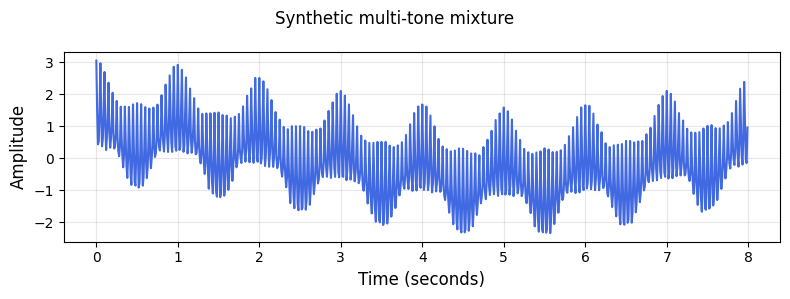

In [2]:
def make_demo(fs: float = 100.0, T: float = 8.0, seed: int = 0):
    rng = np.random.default_rng(seed)
    t = np.arange(0.0, T, 1.0 / fs)
    comps = np.vstack(
        [
            0.75 * np.cos(2 * np.pi * 0.1 * t),
            0.65 * np.cos(2 * np.pi * 1.0 * t),
            1.00 * np.cos(2 * np.pi * 20.0 * t),
            0.30 * np.cos(2 * np.pi * 22.0 * t),
            0.35 * np.cos(2 * np.pi * 40.0 * t),
        ]
    )
    signal = comps.sum(axis=0) + 0.03 * rng.standard_normal(t.size)
    if signal.size % 2:
        t, signal, comps = t[:-1], signal[:-1], comps[:, :-1]
    return t, signal, comps


fs = 100.0
t, signal, comps = make_demo(fs=fs)
print(f"N={signal.size}, fs={fs} Hz, true components={comps.shape[0]}")

fig = plot_signal(t, signal)
fig.suptitle("Synthetic multi-tone mixture", fontsize=12)
plt.tight_layout()
plt.show()

## 5. Run OVMD (and compare with VMD)

| Parameter | Role |
|-----------|------|
| `alpha` | Bandwidth parameter ($2F$ in the paper) |
| `K` | Number of modes (here intentionally oversized) |
| `tau` | Dual ascent step (0 = noise-slack) |
| `tol` | Relative spectral-update stop |

In [5]:
K = 6
alpha = 100.0  # 2F in the paper / example_OVMD.m

ovmd = OVMD(alpha=alpha, K=K, tau=0.0, tol=1e-5, max_iter=400)
u_o, uh_o, om_o = ovmd.fit_transform(signal, return_all=True)

vmd = VMD(alpha=alpha, K=K, tau=0.0, init="zero", tol=1e-5, max_iter=400)
u_v, uh_v, om_v = vmd.fit_transform(signal, return_all=True)

print(f"OVMD iterations stored: {ovmd.n_iter}")
print(f"OVMD final omega (norm. freq): {om_o[-1]}")
print(f"VMD  final omega (norm. freq): {om_v[-1]}")

re_o = np.linalg.norm(u_o.sum(0) - signal) / np.linalg.norm(signal)
re_v = np.linalg.norm(u_v.sum(0) - signal) / np.linalg.norm(signal)
print(f"reconstruction RE  OVMD={re_o:.4e}  VMD={re_v:.4e}")


def max_offdiag_corr(u):
    uc = u - u.mean(axis=1, keepdims=True)
    c = np.corrcoef(uc)
    return float(np.max(np.abs(c - np.eye(c.shape[0]))))


print(f"max |off-diag corr|  OVMD={max_offdiag_corr(u_o):.4f}  VMD={max_offdiag_corr(u_v):.4f}")

OVMD iterations stored: 64
OVMD final omega (norm. freq): [0.1999 0.0008 0.01   0.4    0.2202 0.1249]
VMD  final omega (norm. freq): [0.0047 0.2    0.2202 0.1983 0.4    0.4   ]
reconstruction RE  OVMD=2.7415e-02  VMD=7.0163e-03
max |off-diag corr|  OVMD=0.0320  VMD=1.0000


## 6. Visualize modes and orthogonality

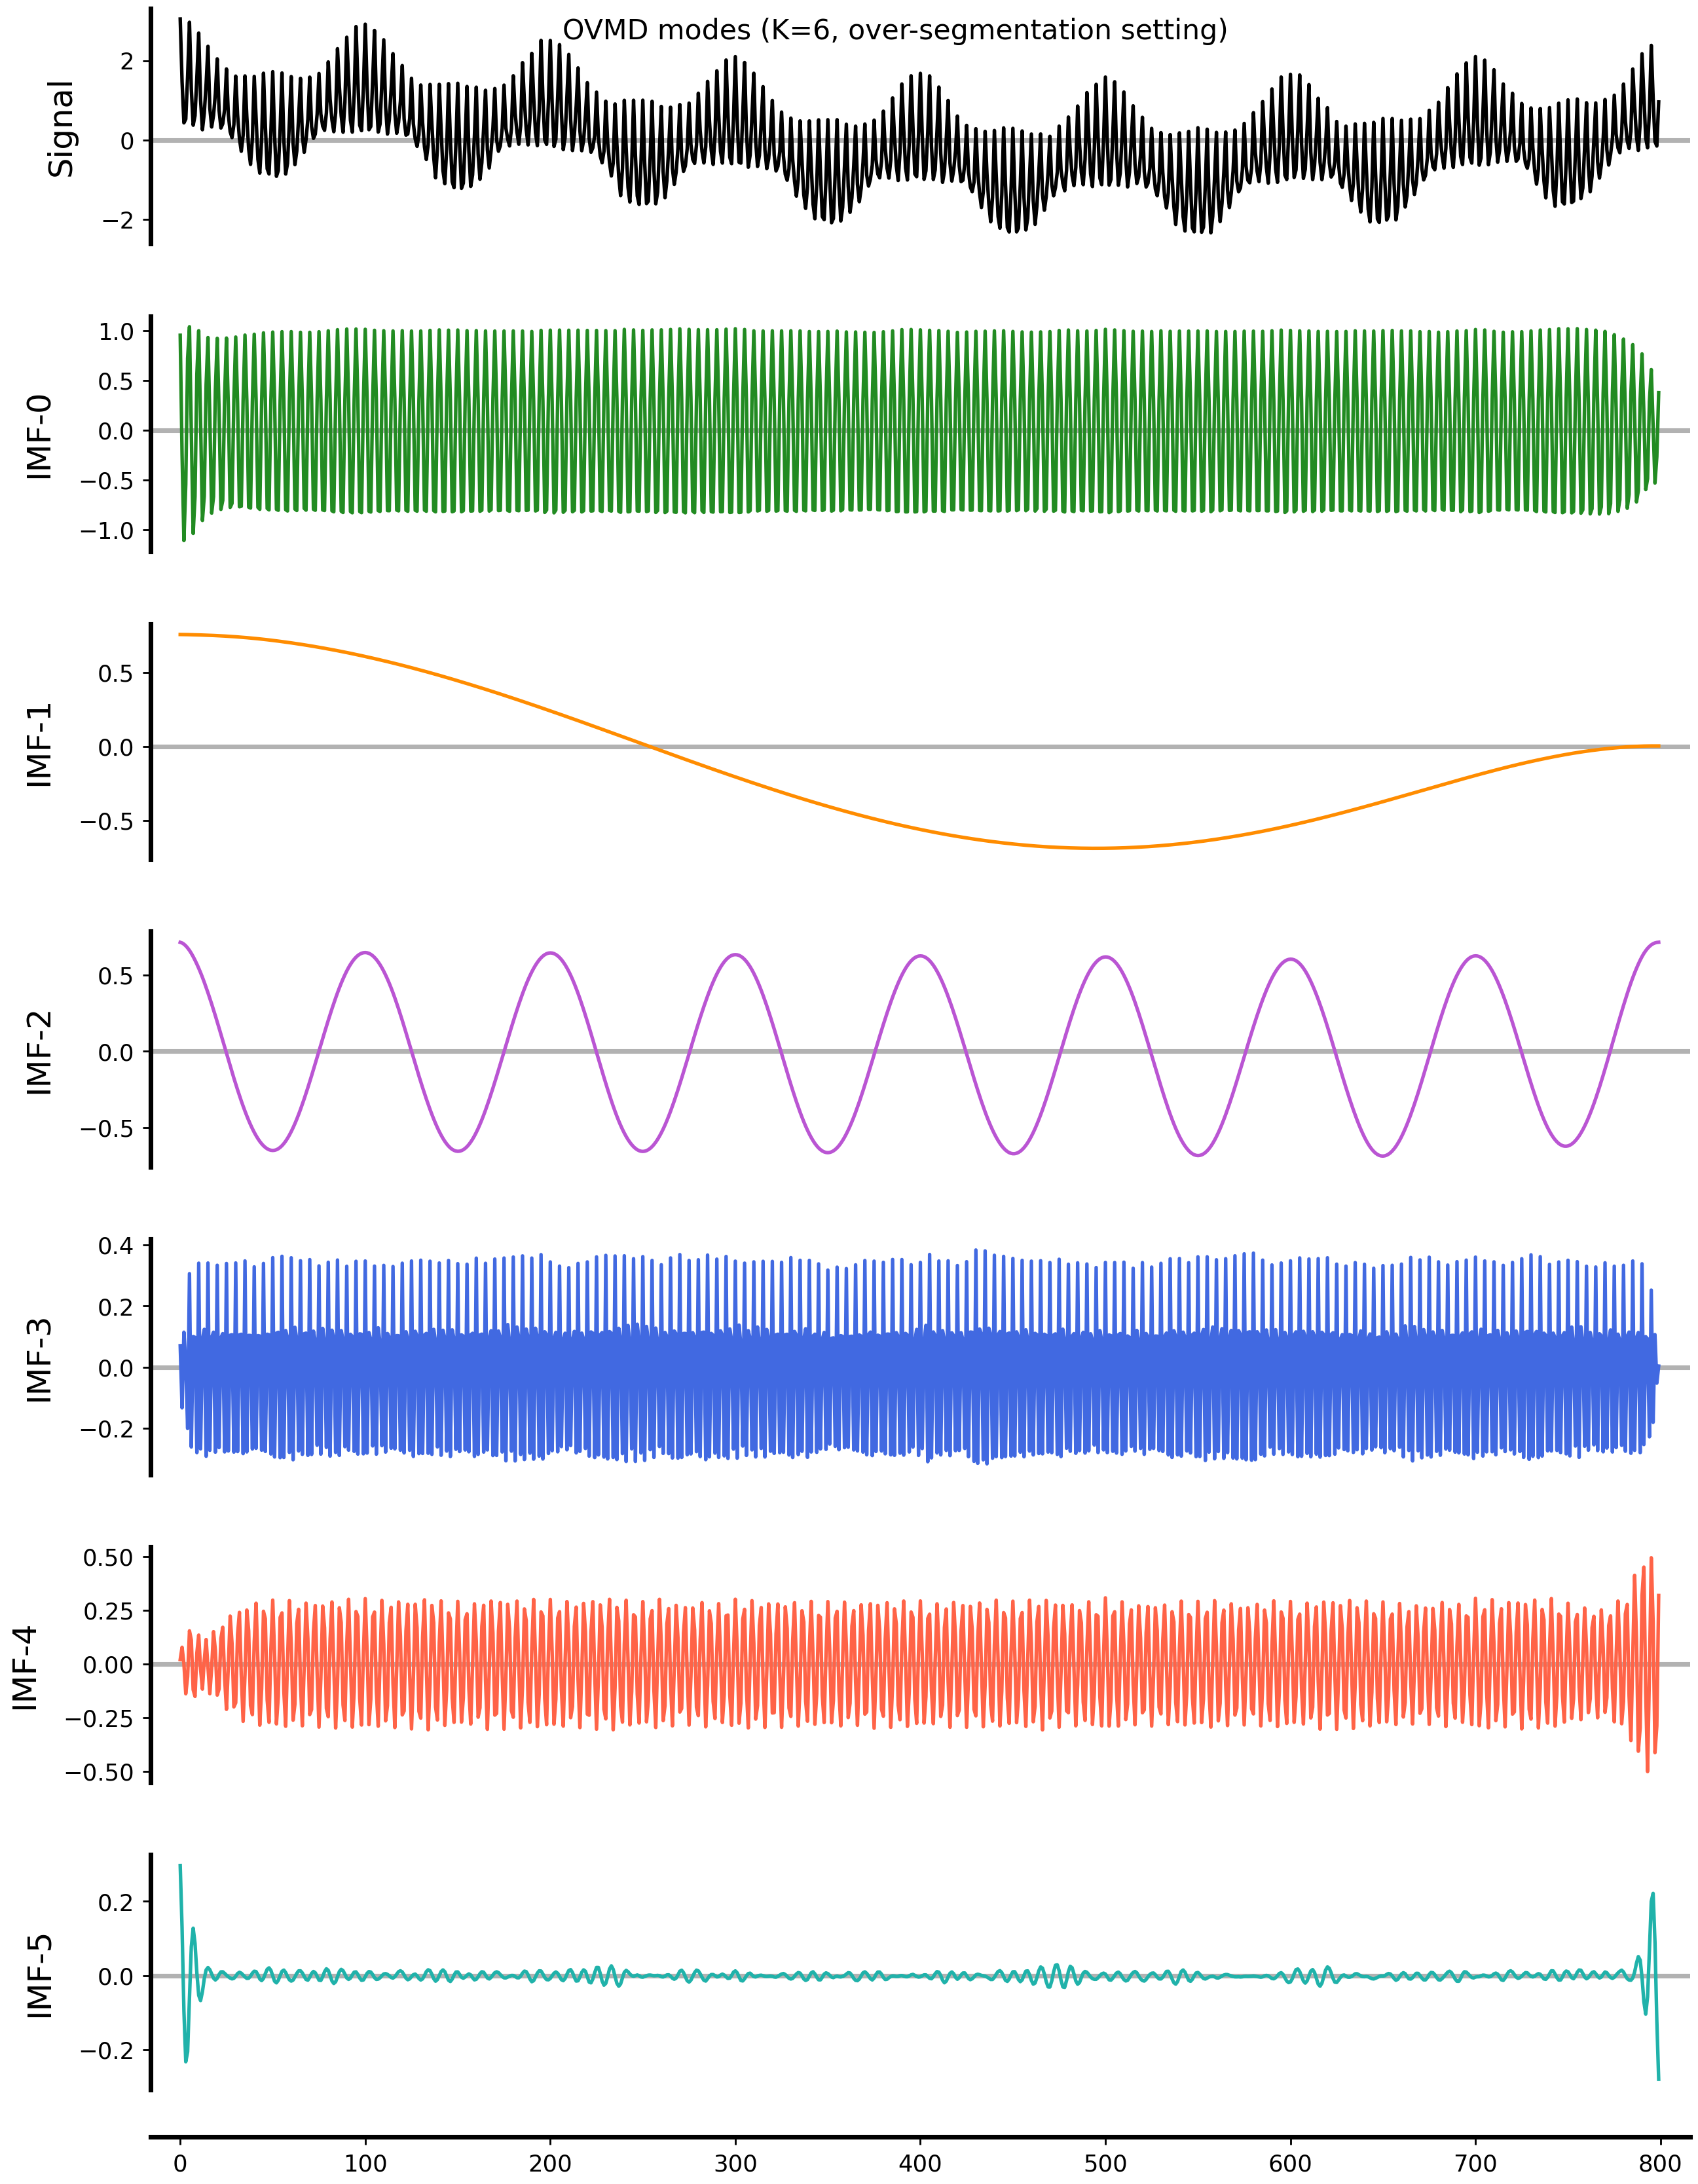

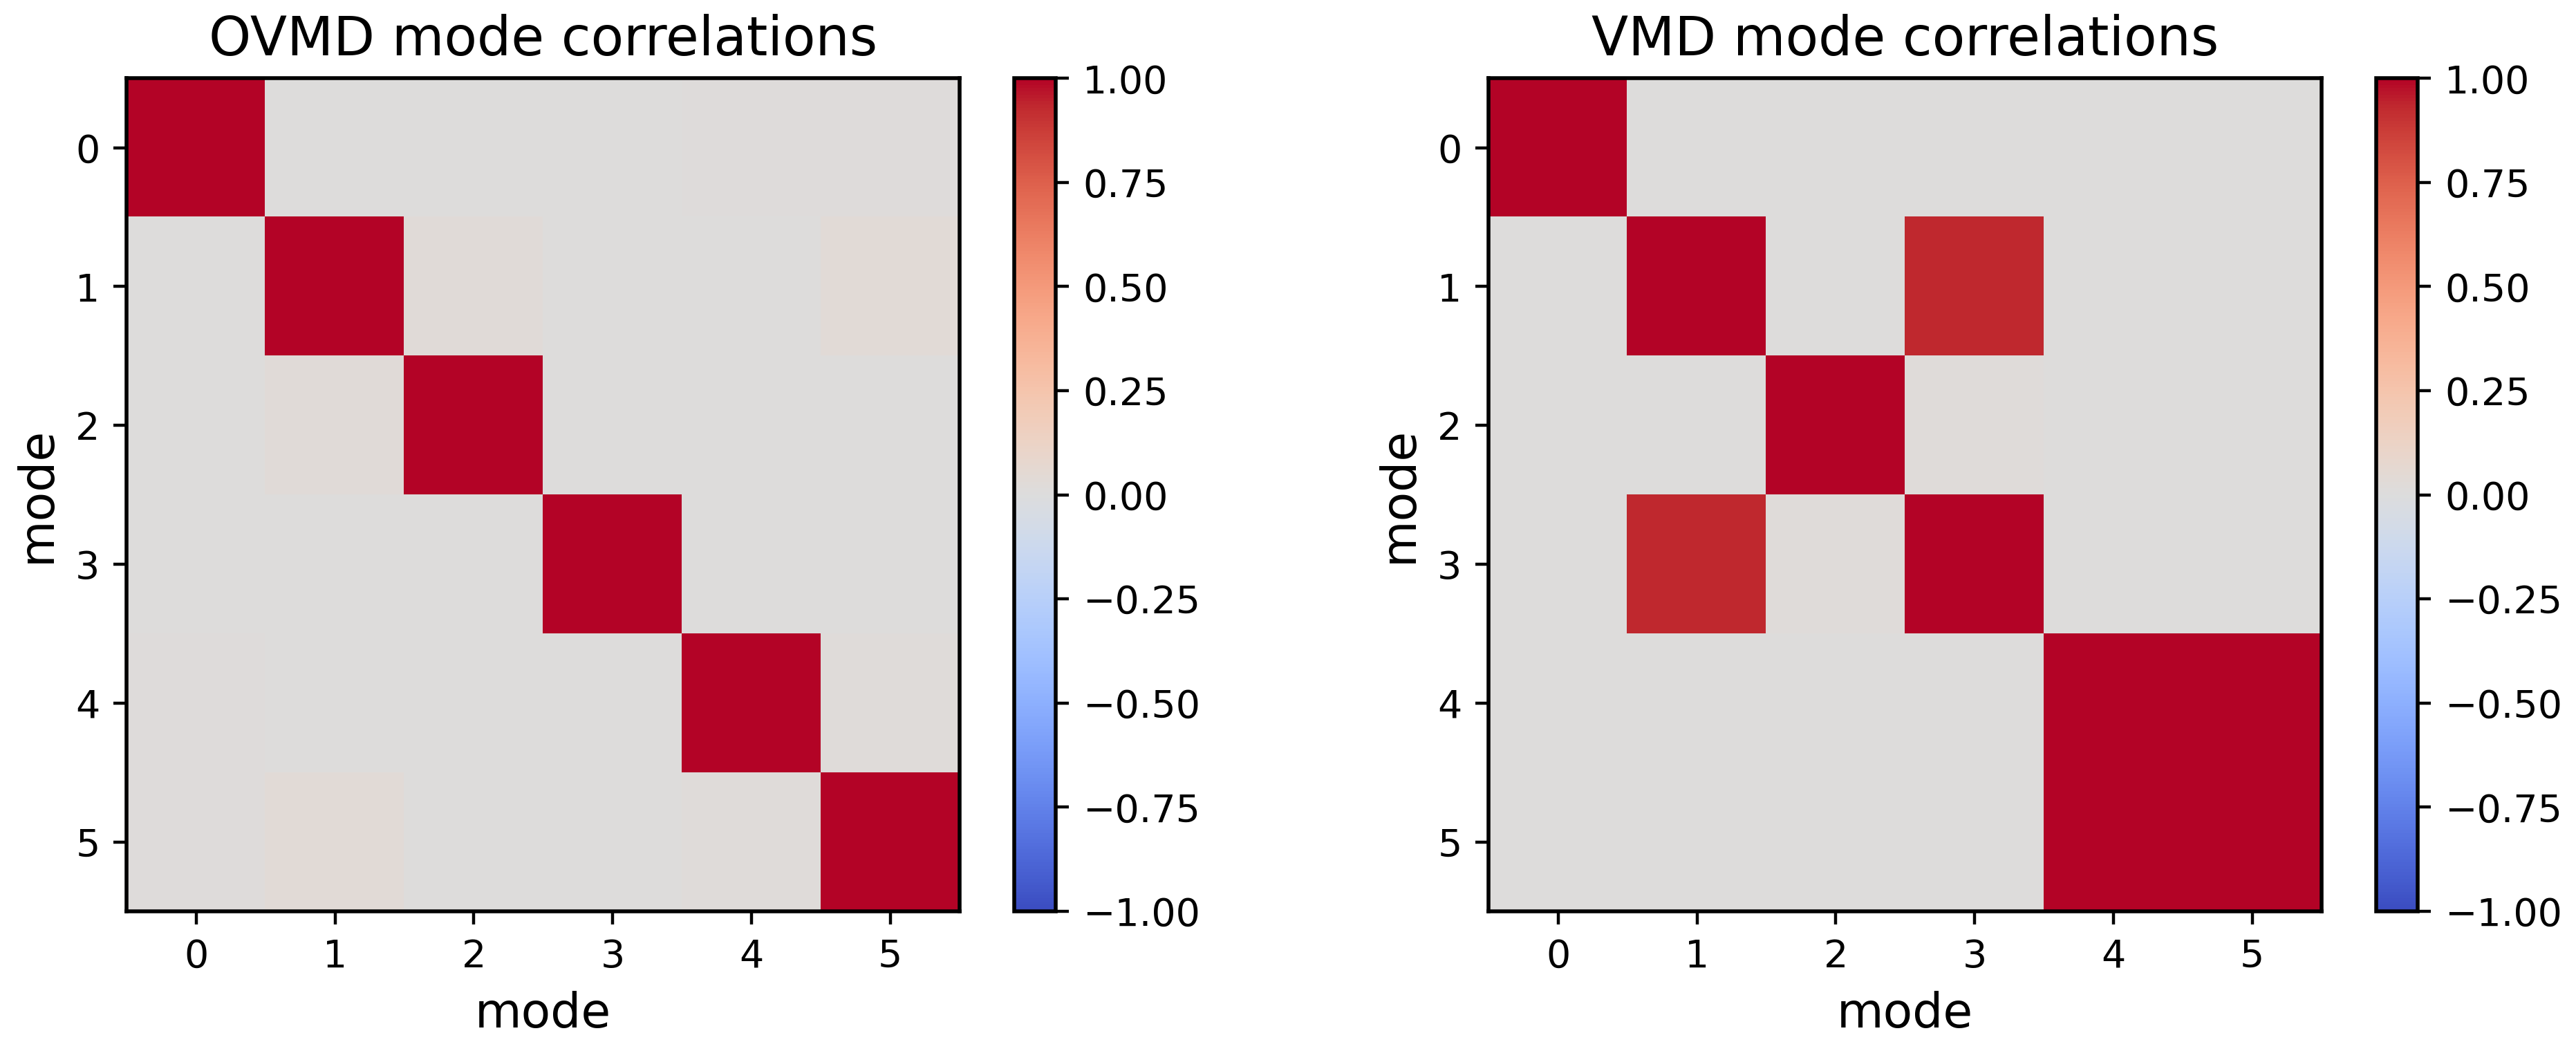

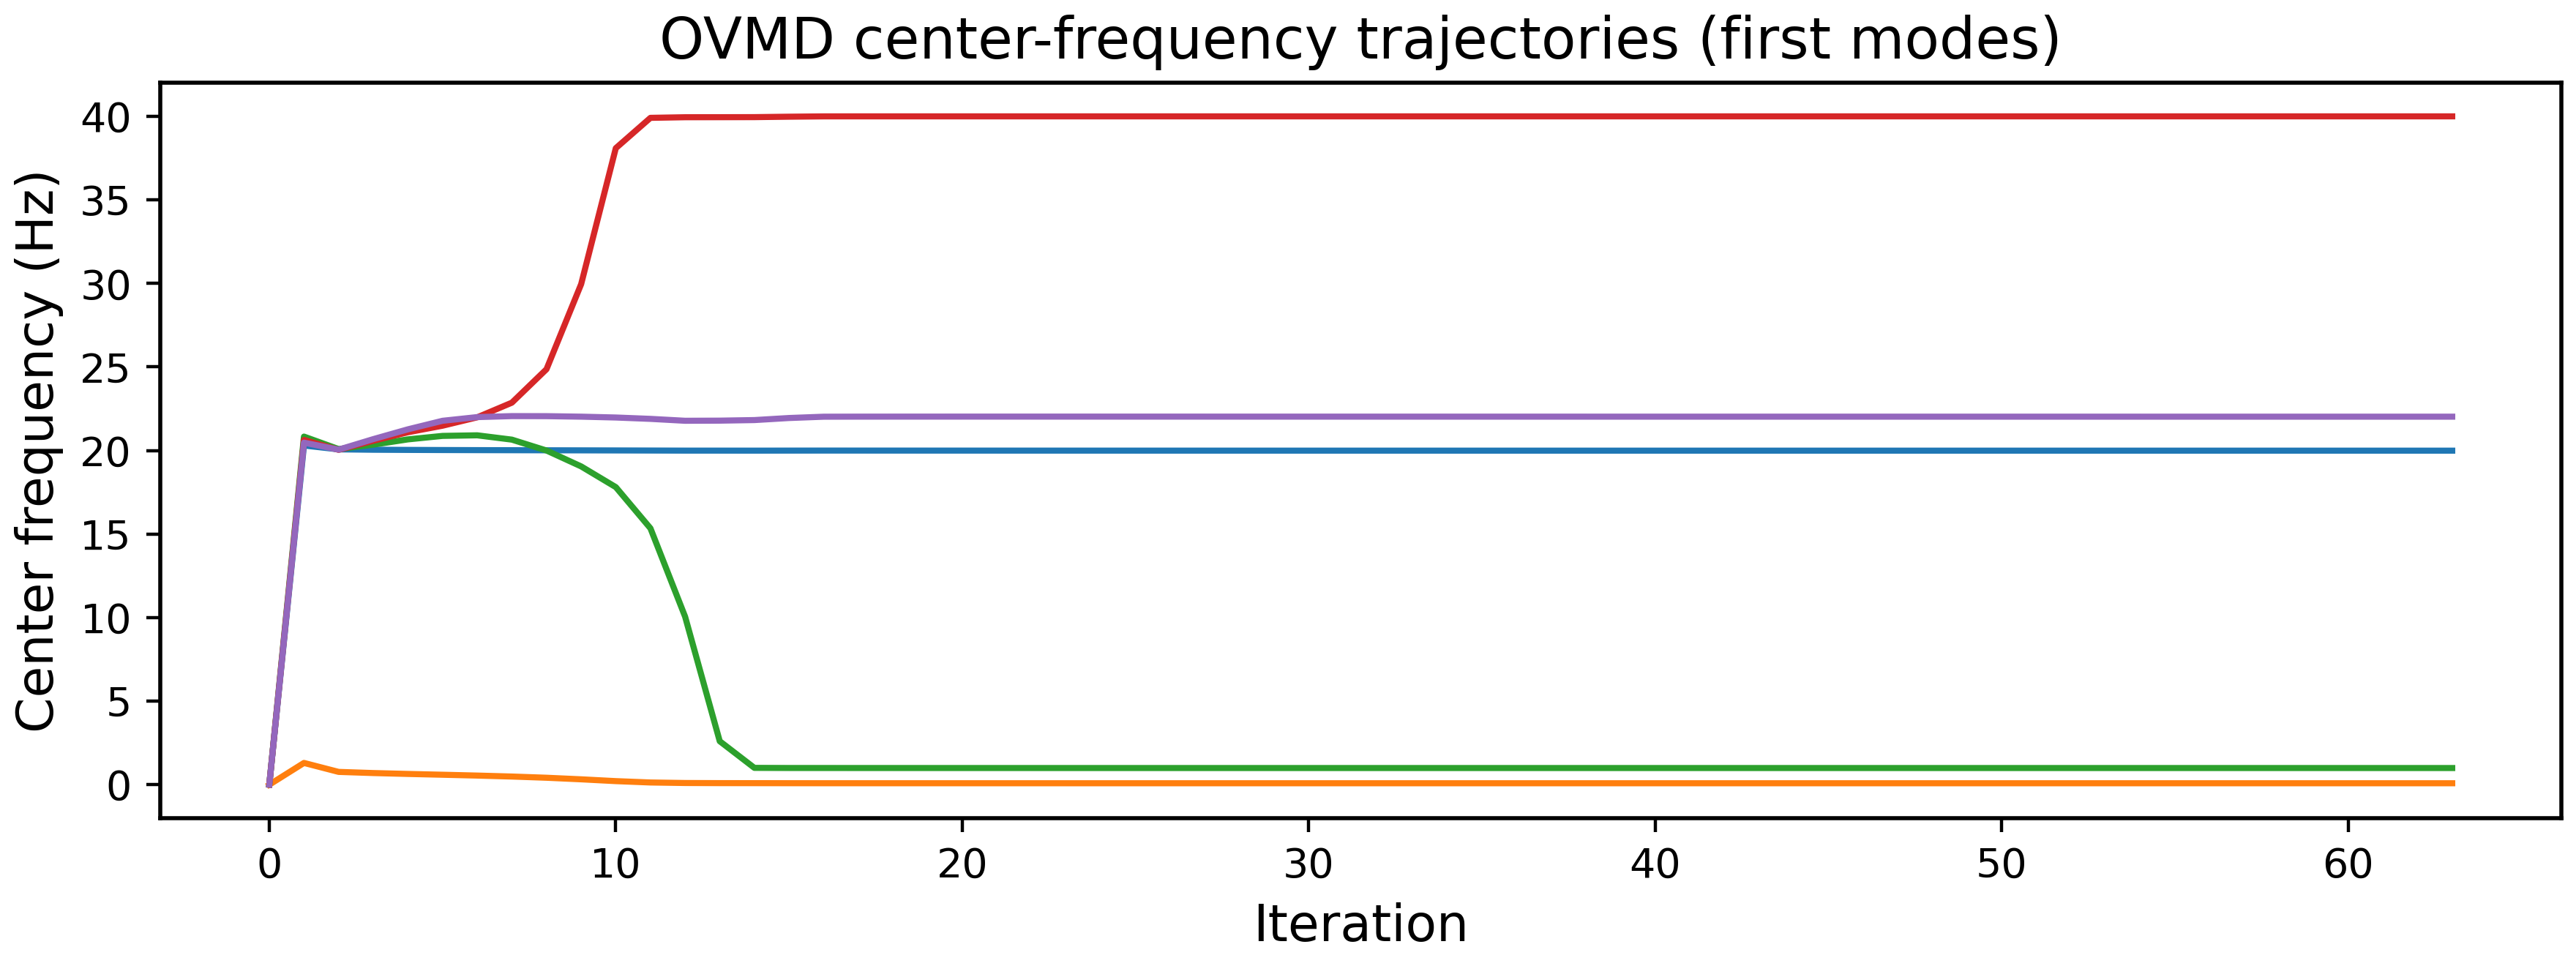

In [6]:
plot_IMFs(signal, u_o)
plt.suptitle(f"OVMD modes (K={K}, over-segmentation setting)", fontsize=12)
plt.show()


def corr_matrix(u):
    uc = u - u.mean(axis=1, keepdims=True)
    return np.corrcoef(uc)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, u, title in zip(
    axes, [u_o, u_v], ["OVMD mode correlations", "VMD mode correlations"]
):
    im = ax.imshow(corr_matrix(u), vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_title(title)
    ax.set_xlabel("mode")
    ax.set_ylabel("mode")
    fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(om_o[:, : min(5, K)] * fs, lw=1.5)
ax.set_xlabel("Iteration")
ax.set_ylabel("Center frequency (Hz)")
ax.set_title("OVMD center-frequency trajectories (first modes)")
plt.tight_layout()
plt.show()

## 7. Takeaways

- OVMD augments VMD with **split orthogonality objectives** driven by spectral coherence and dominant/weaker roles.
- A **proportional** $\alpha_k=\alpha/\omega_k$ adapts bandwidth across the spectrum.
- The combination reduces **mode duplication** when $K$ is chosen larger than necessary.
- In PySDKit: `from pysdkit import OVMD`, then `u = OVMD(alpha=..., K=...).fit_transform(signal)`.

**Further reading**

- Marbona et al., *Orthogonalized Variational Mode Decomposition*, Signal Processing, 2026.
- Dragomiretskiy & Zosso, *Variational Mode Decomposition*, IEEE TSP, 2014.